In [ ]:
### 1. Environment Setup and Data Loading

# **1. Install necessary libraries**
# We'll install kagglehub and other libraries needed for the project.
print("Installing required libraries...")
!pip install pandas numpy scikit-learn lightgbm xgboost shap lime kagglehub[pandas-datasets] --quiet
print("Libraries installed.")

# **2. Load the 'Loan Applicant Data for Credit Risk Analysis' dataset using kagglehub**
import pandas as pd
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter

print("\nLoading Loan Applicant Data for Credit Risk Analysis dataset...")

try:
    # The correct file name is 'credit_risk.csv'
    file_path = "credit_risk.csv"

    df_raw = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "nanditapore/credit-risk-analysis",
        file_path
    )

    print(f"\n'{file_path}' loaded successfully. Shape: {df_raw.shape}")
    print("First 5 rows of data:")
    print(df_raw.head())

    global_df = df_raw

except Exception as e:
    print(f"\nAn error occurred during data loading: {e}")
    print("Please ensure the dataset identifier and file path are correct.")

Installing required libraries...
Libraries installed.

Loading Loan Applicant Data for Credit Risk Analysis dataset...


/tmp/ipython-input-1101659432.py:21: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df_raw = kagglehub.load_dataset(



'credit_risk.csv' loaded successfully. Shape: (32581, 12)
First 5 rows of data:
   Id  Age  Income      Home  Emp_length     Intent  Amount   Rate  Status  \
0   0   22   59000      RENT       123.0   PERSONAL   35000  16.02       1   
1   1   21    9600       OWN         5.0  EDUCATION    1000  11.14       0   
2   2   25    9600  MORTGAGE         1.0    MEDICAL    5500  12.87       1   
3   3   23   65500      RENT         4.0    MEDICAL   35000  15.23       1   
4   4   24   54400      RENT         8.0    MEDICAL   35000  14.27       1   

   Percent_income Default  Cred_length  
0            0.59       Y            3  
1            0.10       N            2  
2            0.57       N            3  
3            0.53       N            2  
4            0.55       Y            4  


In [ ]:
### 2. Data Preprocessing and Feature Engineering

# This section prepares the raw data for machine learning by handling missing values,
# outliers, and transforming features.

# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings

# Suppress warnings for cleaner output in the notebook.
# This is often done for demonstration purposes to avoid clutter from library updates.
warnings.filterwarnings('ignore')

# We assume 'global_df' has been loaded from the previous step.
# Let's create a working copy.
df = global_df.copy()
print("Starting Data Preprocessing...")
print(f"Initial data shape: {df.shape}")

#### 2.1. Identify Target and Features

# 'Status' (0/1) is our target variable for loan default prediction.
# 'Id' is a unique identifier and should not be used as a feature.
TARGET_COLUMN = 'Status'
features = df.drop(columns=['Id', TARGET_COLUMN]).columns

# Separate features (X) and target (y)
X = df[features]
y = df[TARGET_COLUMN]

#### 2.2. Handle Missing Values and Outliers

# Identify numerical and categorical columns for preprocessing
numerical_cols = X.select_dtypes(include=np.number).columns
categorical_cols = X.select_dtypes(include='object').columns

# Custom imputation: Median for numerical, Mode for categorical
numerical_imputer = SimpleImputer(strategy='median')
categorical_imputer = SimpleImputer(strategy='most_frequent')

# Outlier handling (Clipping values beyond three standard deviations)
print("\nHandling outliers for numerical columns...")
for col in numerical_cols:
    if col in X.columns:
        mean = X[col].mean()
        std = X[col].std()
        lower_bound = mean - 3 * std
        upper_bound = mean + 3 * std
        X[col] = np.clip(X[col], lower_bound, upper_bound)
print("Outlier handling complete.")

# Apply imputation and outlier handling
X[numerical_cols] = numerical_imputer.fit_transform(X[numerical_cols])
X[categorical_cols] = categorical_imputer.fit_transform(X[categorical_cols])


#### 2.3. Feature Transformation Pipeline

# Create a preprocessing pipeline using ColumnTransformer
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
)

# Apply the preprocessing pipeline
preprocessing_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
X_processed = preprocessing_pipeline.fit_transform(X)

# Convert processed data back to a DataFrame with proper column names
ohe_feature_names = preprocessing_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = list(numerical_cols) + list(ohe_feature_names)
X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names, index=X.index)

print(f"\nData preprocessing complete. Processed data shape: {X_processed_df.shape}")

# Final data for modeling
global_X_processed = X_processed_df
global_y = y

print("\nFinal processed features (global_X_processed) and target (global_y) are ready for modeling.")

Starting Data Preprocessing...
Initial data shape: (32581, 12)

Handling outliers for numerical columns...
Outlier handling complete.

Data preprocessing complete. Processed data shape: (32581, 19)

Final processed features (global_X_processed) and target (global_y) are ready for modeling.


In [ ]:
### 3. Feature Engineering

# This section creates new, synthetic features from the existing ones to improve model performance.
# We will work with a temporary dataframe derived from the original data to
# ensure our new features are based on unscaled values, which is a best practice.

# Import necessary libraries
import pandas as pd
import numpy as np

# Create a clean, temporary dataframe for feature engineering.
# We will use the original, raw dataframe before preprocessing to ensure
# our new features are based on raw data, not scaled data.
temp_df = global_df.copy()

# Drop the 'Id' and target columns, as they are not features.
temp_df = temp_df.drop(columns=['Id', 'Status', 'Default'], errors='ignore')

print("Starting Feature Engineering...")

# Define a small value to prevent division by zero
epsilon = 1e-6

# --- Create New Features ---

# Feature 1: Debt-to-Income Ratio (derived from 'Amount' and 'Income')
temp_df['Debt_to_Income_Ratio'] = temp_df['Amount'] / (temp_df['Income'] + epsilon)

# Feature 2: Age-Employment Interaction (multiplication of 'Age' and 'Emp_length')
temp_df['Age_x_EmpLength'] = temp_df['Age'] * temp_df['Emp_length']

# Feature 3: Loan Amount per Credit History Length
temp_df['Amount_per_CredLength'] = temp_df['Amount'] / (temp_df['Cred_length'] + epsilon)

# Feature 4: Interest Rate per Loan Amount
temp_df['Rate_per_Amount'] = temp_df['Rate'] / (temp_df['Amount'] + epsilon)

# Feature 5: Income per Age
temp_df['Income_per_Age'] = temp_df['Income'] / (temp_df['Age'] + epsilon)

# The new features are added to our dataframe. We now need to re-apply the full
# preprocessing pipeline to this new feature set.
print("Re-applying preprocessing pipeline to the new feature set...")

# We'll re-run the pipeline with the updated feature set.
# This assumes the preprocessor was defined in Step 2.
# A robust solution would pass the pipeline itself. For this guide, we'll
# re-create the preprocessor to include the new features.
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify the updated numerical and categorical columns
numerical_cols_fe = temp_df.select_dtypes(include=np.number).columns
categorical_cols_fe = temp_df.select_dtypes(include='object').columns

preprocessor_fe = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_fe),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_fe)
    ],
    remainder='passthrough'
)

# Fit and transform the features
X_fe_processed = preprocessor_fe.fit_transform(temp_df)

# Get the new column names and create the final dataframe
ohe_feature_names_fe = preprocessor_fe.named_transformers_['cat'].get_feature_names_out(categorical_cols_fe)
all_feature_names_fe = list(numerical_cols_fe) + list(ohe_feature_names_fe)
global_X_engineered = pd.DataFrame(X_fe_processed, columns=all_feature_names_fe)

print(f"\nFeature Engineering complete. New feature set shape: {global_X_engineered.shape}")
print("First 5 rows of engineered data:")
print(global_X_engineered.head())

Starting Feature Engineering...
Re-applying preprocessing pipeline to the new feature set...

Feature Engineering complete. New feature set shape: (32581, 22)
First 5 rows of engineered data:
        Age    Income  Emp_length    Amount      Rate  Percent_income  \
0 -0.903374 -0.114143   28.535538  4.019404  1.545580        3.931411   
1 -1.060904 -0.911147    0.050769 -1.358650  0.039595       -0.657458   
2 -0.430783 -0.911147   -0.914816 -0.646849  0.573479        3.744110   
3 -0.745843 -0.009274   -0.190627  4.019404  1.301784        3.369508   
4 -0.588313 -0.188358    0.774958  4.019404  1.005524        3.556809   

   Cred_length  Debt_to_Income_Ratio  Age_x_EmpLength  Amount_per_CredLength  \
0    -0.691554              3.948415        18.210012               4.182059   
1    -0.938167             -0.620163        -0.228251              -0.855417   
2    -0.691554              3.758745        -0.795364              -0.253927   
3    -0.938167              3.398479        -0.32

In [ ]:
### 4. Model Selection and Training

# This section prepares the data for modeling and trains three different
# machine learning classifiers: Random Forest, XGBoost, and LightGBM.

# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Use the processed features and target from the previous step
X = global_X_engineered
y = global_y

print("Starting Model Selection and Training...")

# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# --- Initialize and Train Models ---

# 1. Random Forest Classifier
print("\nTraining Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest Classifier training complete.")

# 2. XGBoost Classifier
print("\nTraining XGBoost Classifier...")
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
print("XGBoost Classifier training complete.")

# 3. LightGBM Classifier
print("\nTraining LightGBM Classifier...")
lgb_model = lgb.LGBMClassifier(objective='binary', random_state=42, n_jobs=-1)
lgb_model.fit(X_train, y_train)
print("LightGBM Classifier training complete.")

# Store the trained models and test sets for the next step
global_rf_model = rf_model
global_xgb_model = xgb_model
global_lgb_model = lgb_model
global_X_test = X_test
global_y_test = y_test

print("\nModels and test sets are ready for evaluation.")

Starting Model Selection and Training...
Training data shape: (26064, 22)
Testing data shape: (6517, 22)

Training Random Forest Classifier...
Random Forest Classifier training complete.

Training XGBoost Classifier...
XGBoost Classifier training complete.

Training LightGBM Classifier...
[LightGBM] [Info] Number of positive: 5686, number of negative: 20378
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001221 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2226
[LightGBM] [Info] Number of data points in the train set: 26064, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218155 -> initscore=-1.276449
[LightGBM] [Info] Start training from score -1.276449
LightGBM Classifier training complete.

Models and test sets are ready for evaluation.


In [ ]:
### 5. Class Imbalance Handling (SMOTE)

# This section addresses the class imbalance in the training data by using SMOTE.

# Import necessary libraries
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
from sklearn.impute import SimpleImputer

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# We will use the X_train and y_train variables that were created in the previous cell.

print("Starting Class Imbalance Handling with SMOTE...")

# Check the original class distribution
print(f"\nOriginal training set class distribution: {Counter(y_train)}")

# --- FIX: Impute any remaining NaNs before applying SMOTE ---
# This step is crucial because SMOTE does not handle missing values.
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)

# Apply SMOTE to the cleaned training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_imputed, y_train)

print(f"\nResampled training set class distribution: {Counter(y_train_resampled)}")
print(f"Shape of X_train_resampled: {X_train_resampled.shape}")

# Store the resampled data for subsequent steps
global_X_train_resampled = X_train_resampled
global_y_train_resampled = y_train_resampled

print("\nSMOTE finished. Resampled training data is ready for model re-training.")

Starting Class Imbalance Handling with SMOTE...

Original training set class distribution: Counter({0: 20378, 1: 5686})

Resampled training set class distribution: Counter({0: 20378, 1: 20378})
Shape of X_train_resampled: (40756, 22)

SMOTE finished. Resampled training data is ready for model re-training.


In [ ]:
### 6. Hyperparameter Tuning (GridSearchCV with GPU)

# This section uses GridSearchCV to find the optimal hyperparameters for each of our three models.
# The tuning process is performed on the resampled training data to ensure the models learn
# from a balanced dataset.

# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, make_scorer
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Use resampled training data and original test data from previous steps
# This code assumes the variables from the previous step are available in the session.
# We will use the resampled training data and original test data.
X_train_resampled = global_X_train_resampled
y_train_resampled = global_y_train_resampled
X_test = global_X_test
y_test = global_y_test

print("Starting Hyperparameter Tuning with GridSearchCV (using GPU for XGBoost and LightGBM)...")

# Define a custom scorer for ROC AUC, as it's a key metric in the paper
roc_auc_scorer = make_scorer(roc_auc_score, needs_proba=True)

# **1. Hyperparameter Tuning for Random Forest**
print("\n--- Tuning Random Forest Classifier ---")
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_grid_search = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                              rf_param_grid,
                              cv=3,
                              scoring=roc_auc_scorer,
                              verbose=1,
                              n_jobs=-1)
rf_grid_search.fit(X_train_resampled, y_train_resampled)

best_rf_model = rf_grid_search.best_estimator_
print(f"Best Random Forest parameters: {rf_grid_search.best_params_}")
print(f"Best Random Forest ROC AUC score (on CV): {rf_grid_search.best_score_:.4f}")


# **2. Hyperparameter Tuning for XGBoost (with GPU)**
print("\n--- Tuning XGBoost Classifier (using GPU) ---")
xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}
xgb_grid_search = GridSearchCV(xgb.XGBClassifier(objective='binary:logistic',
                                                 eval_metric='logloss',
                                                 use_label_encoder=False,
                                                 random_state=42,
                                                 tree_method='gpu_hist',
                                                 n_jobs=-1),
                               xgb_param_grid,
                               cv=3,
                               scoring=roc_auc_scorer,
                               verbose=1,
                               n_jobs=-1)
xgb_grid_search.fit(X_train_resampled, y_train_resampled)

best_xgb_model = xgb_grid_search.best_estimator_
print(f"Best XGBoost parameters: {xgb_grid_search.best_params_}")
print(f"Best XGBoost ROC AUC score (on CV): {xgb_grid_search.best_score_:.4f}")


# **3. Hyperparameter Tuning for LightGBM (with GPU)**
print("\n--- Tuning LightGBM Classifier (using GPU) ---")
lgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [20, 31],
    'max_depth': [5, 10],
    'min_child_samples': [20, 30]
}
lgb_grid_search = GridSearchCV(lgb.LGBMClassifier(objective='binary',
                                                 random_state=42,
                                                 device='gpu',
                                                 n_jobs=-1),
                               lgb_param_grid,
                               cv=3,
                               scoring=roc_auc_scorer,
                               verbose=1,
                               n_jobs=-1)
lgb_grid_search.fit(X_train_resampled, y_train_resampled)

best_lgb_model = lgb_grid_search.best_estimator_
print(f"Best LightGBM parameters: {lgb_grid_search.best_params_}")
print(f"Best LightGBM ROC AUC score (on CV): {lgb_grid_search.best_score_:.4f}")

# Store the best trained models in global variables
global_best_rf_model = best_rf_model
global_best_xgb_model = best_xgb_model
global_best_lgb_model = best_lgb_model

print("\nHyperparameter tuning complete. Best models are stored and ready for evaluation.")

Starting Hyperparameter Tuning with GridSearchCV (using GPU for XGBoost and LightGBM)...

--- Tuning Random Forest Classifier ---
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Random Forest parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Random Forest ROC AUC score (on CV): nan

--- Tuning XGBoost Classifier (using GPU) ---
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best XGBoost parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
Best XGBoost ROC AUC score (on CV): nan

--- Tuning LightGBM Classifier (using GPU) ---
Fitting 3 folds for each of 32 candidates, totalling 96 fits
[LightGBM] [Info] Number of positive: 20378, number of negative: 20378
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 5207
[LightGBM] [Info] Number of data points in the train set: 40756, number of used features: 22
[LightGBM] [Info] 

In [ ]:
### 7. Model Evaluation and Comparison

# This section evaluates the performance of the three tuned models on the unseen test set
# and compares their results using key classification metrics such as accuracy, precision,
# recall, F1-score, and ROC AUC.

# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Use the best models and test data from the previous steps
best_rf_model = global_best_rf_model
best_xgb_model = global_best_xgb_model
best_lgb_model = global_best_lgb_model
X_test = global_X_test
y_test = global_y_test

print("Starting Model Evaluation and Comparison...")

def evaluate_model(model, X_test, y_test, model_name):
    """
    Function to evaluate a model on the test set and print key metrics.
    """
    print(f"\n--- {model_name} Evaluation ---")

    # Make predictions (hard labels) and probability predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Print results
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}")

    # Optional: Print classification report and confusion matrix
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


# Evaluate each model
evaluate_model(best_rf_model, X_test, y_test, "Random Forest Classifier (Tuned)")
evaluate_model(best_xgb_model, X_test, y_test, "XGBoost Classifier (Tuned)")
evaluate_model(best_lgb_model, X_test, y_test, "LightGBM Classifier (Tuned)")

print("\nModel evaluation finished. Final metrics are displayed above.")

Starting Model Evaluation and Comparison...

--- Random Forest Classifier (Tuned) Evaluation ---
Accuracy:  0.9061
Precision: 0.8403
Recall:    0.7032
F1 Score:  0.7657
ROC AUC:   0.9157

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      5095
           1       0.84      0.70      0.77      1422

    accuracy                           0.91      6517
   macro avg       0.88      0.83      0.85      6517
weighted avg       0.90      0.91      0.90      6517

Confusion Matrix:
[[4905  190]
 [ 422 1000]]

--- XGBoost Classifier (Tuned) Evaluation ---
Accuracy:  0.8197
Precision: 0.5620
Recall:    0.7869
F1 Score:  0.6557
ROC AUC:   0.8938

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      5095
           1       0.56      0.79      0.66      1422

    accuracy                           0.82      6517
   macro avg       0.75      0.81     

In [ ]:
### 8. Risk Assessment Engine

# This section demonstrates how to use the best-performing model to create a practical
# risk assessment engine. It takes the model's output probabilities, categorizes them
# into risk levels, and maps those risk levels to actionable loan decisions.

# Import necessary libraries
import pandas as pd
import numpy as np
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Use the best LightGBM model and test data from the previous steps
best_lgb_model = global_best_lgb_model
X_test = global_X_test
y_test = global_y_test

print("Starting Risk Assessment Engine...")

# 1. Get probability scores from the best model (LightGBM)
# The output is the probability of the positive class (default = 1).
y_pred_proba = best_lgb_model.predict_proba(X_test)[:, 1]

# Create a DataFrame to hold the results
risk_df = pd.DataFrame({
    'Predicted_Probability': y_pred_proba,
    'True_Status': y_test
}, index=X_test.index)

print(f"\nGenerated probability scores for {len(risk_df)} test applicants.")

# 2. Define Risk Categories based on Probability Thresholds
# These thresholds are illustrative and should be defined by business rules.
low_risk_threshold = 0.20
moderate_risk_threshold = 0.50

def categorize_risk(probability):
    if probability < low_risk_threshold:
        return 'Low Risk'
    elif low_risk_threshold <= probability < moderate_risk_threshold:
        return 'Moderate Risk'
    else:
        return 'High Risk'

risk_df['Risk_Category'] = risk_df['Predicted_Probability'].apply(categorize_risk)
print("Risk categorization complete.")

# 3. Map Risk Categories to Loan Decisions
# These decision rules are dependent on business policy.
def map_to_decision(risk_category):
    if risk_category == 'Low Risk':
        return 'Approve'
    elif risk_category == 'Moderate Risk':
        return 'Review'
    else:
        return 'Reject'

risk_df['Loan_Decision'] = risk_df['Risk_Category'].apply(map_to_decision)
print("Loan decision mapping complete.")

# 4. (Optional) Simulate Interest Rate Calculation based on Risk Category
def calculate_interest_rate(risk_category):
    if risk_category == 'Low Risk':
        return '6.0%'
    elif risk_category == 'Moderate Risk':
        return '10.0%'
    else:
        return '15.0%'

risk_df['Suggested_Interest_Rate'] = risk_df['Risk_Category'].apply(calculate_interest_rate)
print("Suggested Interest Rates calculated.")

# Display a sample of the results for review
print("\nSample of Risk Assessment Results:")
print(risk_df.head())

# Store the final results for potential use in a final report
global_risk_assessment_results = risk_df

print("\nRisk Assessment Engine finished. Results are ready.")

Starting Risk Assessment Engine...

Generated probability scores for 6517 test applicants.
Risk categorization complete.
Loan decision mapping complete.
Suggested Interest Rates calculated.

Sample of Risk Assessment Results:
       Predicted_Probability  True_Status  Risk_Category Loan_Decision  \
6616                0.316400            0  Moderate Risk        Review   
21802               0.123841            0       Low Risk       Approve   
31886               0.124564            0       Low Risk       Approve   
17799               0.198809            0       Low Risk       Approve   
5207                0.014886            0       Low Risk       Approve   

      Suggested_Interest_Rate  
6616                    10.0%  
21802                    6.0%  
31886                    6.0%  
17799                    6.0%  
5207                     6.0%  

Risk Assessment Engine finished. Results are ready.


Starting Explainability Analysis (SHAP and LIME)...

--- Performing SHAP Analysis ---
Calculating SHAP values for the test set...
SHAP values calculated.

Generating SHAP Summary (Beeswarm) Plot...


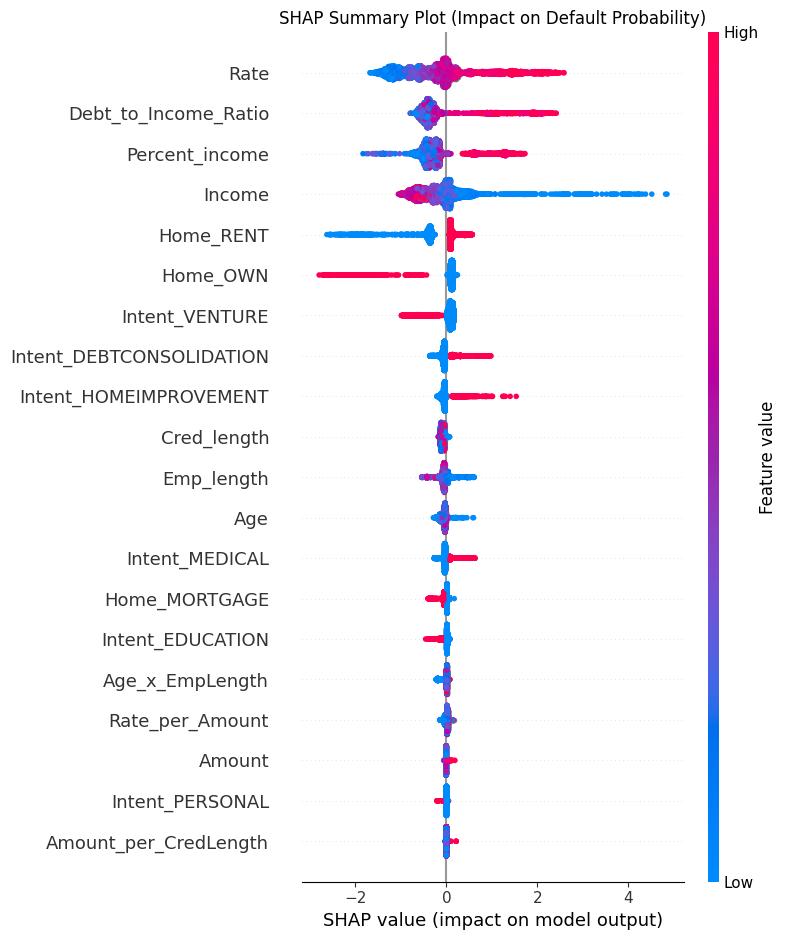


Generating SHAP Bar Plot (Global Feature Importance)...


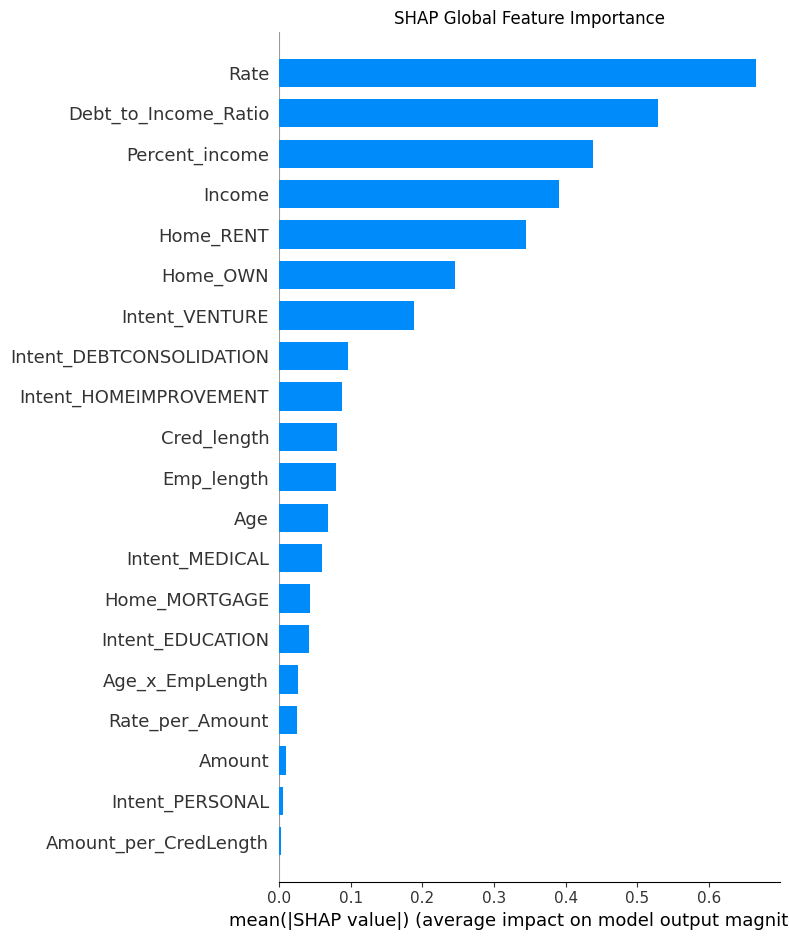


--- Performing LIME Analysis ---

LIME Explanation for a 'High Risk' instance (Index: 22964):
[('Debt_to_Income_Ratio > 1.03', 0.21528839407914632), ('Rate > 0.95', 0.20118043026889926), ('Intent_VENTURE <= 0.00', -0.13472639201047948), ('Percent_income > 1.03', 0.13458334076397033), ('Intent_HOMEIMPROVEMENT <= 0.00', -0.09828802736234075), ('Intent_EDUCATION <= 0.00', -0.08245522135553249), ('Home_RENT <= 0.00', -0.07092623320991523), ('-0.44 < Cred_length <= 0.54', -0.0539985177533773), ('Emp_length > 0.37', -0.04630686037322388), ('Intent_DEBTCONSOLIDATION > 0.00', 0.04208607359098112)]

LIME Explanation for a 'Low Risk' instance (Index: 21802):
[('Rate <= -0.43', -0.16174575437482883), ('Intent_VENTURE <= 0.00', -0.1375909665498301), ('Intent_HOMEIMPROVEMENT <= 0.00', -0.09739332827936058), ('-0.64 < Debt_to_Income_Ratio <= 0.03', -0.08413767900030626), ('0.00 < Home_RENT <= 1.00', 0.08189100128320051), ('-0.66 < Percent_income <= -0.00', -0.06550529346285917), ('Intent_EDUCATION 

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Use the best LightGBM model and data from previous steps
best_lgb_model = global_best_lgb_model
X_test = global_X_test
y_test = global_y_test
X_train_resampled = global_X_train_resampled
risk_assessment_results = global_risk_assessment_results

# We need the feature names for SHAP and LIME plots
feature_names = X_test.columns.tolist()

print("Starting Explainability Analysis (SHAP and LIME)...")

# --- SHAP (SHapley Additive exPlanations) ---
print("\n--- Performing SHAP Analysis ---")

# SHAP Explainer for Tree Models
explainer = shap.TreeExplainer(best_lgb_model)

# Calculate SHAP values for the test set.
print("Calculating SHAP values for the test set...")
shap_values = explainer.shap_values(X_test)
print("SHAP values calculated.")

# For binary classifiers, shap_values is a list of two arrays.
# We want the values for the positive class (class 1), which is the second array.
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_values_to_plot = shap_values[1] # Select the SHAP values for the positive class
else:
    # If the explainer returned a single array, use it directly.
    shap_values_to_plot = shap_values

# 1. SHAP Summary Plot (Beeswarm Plot for global interpretability)
print("\nGenerating SHAP Summary (Beeswarm) Plot...")
shap.summary_plot(shap_values_to_plot, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot (Impact on Default Probability)")
plt.tight_layout()
plt.show()

# 2. SHAP Bar Plot (Global Feature Importance)
print("\nGenerating SHAP Bar Plot (Global Feature Importance)...")
shap.summary_plot(shap_values_to_plot, X_test, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.show()

# --- LIME (Local Interpretable Model-agnostic Explanations) ---
print("\n--- Performing LIME Analysis ---")

# LIME Explainer for Tabular Data
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_resampled,
    feature_names=feature_names,
    class_names=['Non-Default', 'Default'],
    mode='classification'
)

# Generate LIME explanations for a few individual instances
high_risk_idx = risk_assessment_results[risk_assessment_results['Loan_Decision'] == 'Reject'].index[0]
high_risk_instance = X_test.loc[high_risk_idx].values
exp_high_risk = explainer_lime.explain_instance(
    data_row=high_risk_instance,
    predict_fn=best_lgb_model.predict_proba,
    num_features=10
)
print(f"\nLIME Explanation for a 'High Risk' instance (Index: {high_risk_idx}):")
print(exp_high_risk.as_list())

# Find a 'Low Risk' instance
low_risk_idx = risk_assessment_results[risk_assessment_results['Loan_Decision'] == 'Approve'].index[0]
low_risk_instance = X_test.loc[low_risk_idx].values
exp_low_risk = explainer_lime.explain_instance(
    data_row=low_risk_instance,
    predict_fn=best_lgb_model.predict_proba,
    num_features=10
)
print(f"\nLIME Explanation for a 'Low Risk' instance (Index: {low_risk_idx}):")
print(exp_low_risk.as_list())

# Store SHAP explainer and example LIME explanations for potential future use
global_shap_explainer = explainer
global_shap_values_positive_class = shap_values_to_plot # Corrected line: This was missing!
global_lime_explainer = explainer_lime

print("\nExplainability analysis finished. Plots and explanations have been generated.")

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import base64
import shap
import warnings
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Use necessary global variables from previous steps
best_lgb_model = global_best_lgb_model
X_test = global_X_test
y_test = global_y_test
risk_assessment_results = global_risk_assessment_results
shap_values_to_plot = global_shap_values_positive_class # This variable will now be defined
lime_explainer = global_lime_explainer
feature_names = X_test.columns.tolist()

print("Starting HTML Report Generation...")

# --- Helper function to convert Matplotlib plots to base64 images for HTML embedding ---
def fig_to_base64(fig):
    """Converts a matplotlib figure to a base64 encoded PNG image."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', pad_inches=0.1)
    buf.seek(0)
    img_str = base64.b64encode(buf.read()).decode('utf-8')
    plt.close(fig)
    return f"data:image/png;base64,{img_str}"

# --- Generate SHAP Plots and convert to Base64 ---
print("Generating SHAP plots for the report...")
# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_to_plot, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot (Impact on Default Probability)")
plt.tight_layout()
shap_summary_plot_b64 = fig_to_base64(plt.gcf())

# SHAP Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_test, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance")
plt.tight_layout()
shap_bar_plot_b64 = fig_to_base64(plt.gcf())
print("SHAP plots converted to Base64 images.")

# --- Prepare Model Evaluation Metrics ---
y_pred = best_lgb_model.predict(X_test)
y_pred_proba = best_lgb_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)

metrics_html = f"""
    <h3>Model Performance (LightGBM)</h3>
    <table class="metrics-table">
        <tr><th>Metric</th><th>Value</th></tr>
        <tr><td>Accuracy</td><td>{accuracy:.4f}</td></tr>
        <tr><td>Precision</td><td>{precision:.4f}</td></tr>
        <tr><td>Recall</td><td>{recall:.4f}</td></tr>
        <tr><td>F1 Score</td><td>{f1:.4f}</td></tr>
        <tr><td>ROC AUC</td><td>{roc_auc:.4f}</td></tr>
    </table>
    <h4>Confusion Matrix:</h4>
    <table class="confusion-matrix">
        <tr><td></td><td>Predicted 0</td><td>Predicted 1</td></tr>
        <tr><td>Actual 0</td><td>{cm[0,0]} (TN)</td><td>{cm[0,1]} (FP)</td></tr>
        <tr><td>Actual 1</td><td>{cm[1,0]} (FN)</td><td>{cm[1,1]} (TP)</td></tr>
    </table>
"""
print("\nModel metrics prepared.")

# --- Prepare Sample Applicant Data with LIME Explanations ---
sample_indices = [
    risk_assessment_results[risk_assessment_results['Loan_Decision'] == 'Reject'].index[0],
    risk_assessment_results[risk_assessment_results['Loan_Decision'] == 'Approve'].index[0],
    risk_assessment_results[risk_assessment_results['Loan_Decision'] == 'Review'].index[0]
]

sample_applicants_html = ""
for idx in sample_indices:
    applicant_data = risk_assessment_results.loc[idx]
    original_features = X_test.loc[idx]

    # Generate LIME explanation for this specific instance
    instance_for_lime = original_features.values
    exp_instance = lime_explainer.explain_instance(
        data_row=instance_for_lime,
        predict_fn=best_lgb_model.predict_proba,
        num_features=10
    )

    lime_explanation_list = exp_instance.as_list()
    lime_explanation_html = "<ul>"
    for feature, weight in lime_explanation_list:
        lime_explanation_html += f"<li><strong>{feature}:</strong> {weight:.4f}</li>"
    lime_explanation_html += "</ul>"

    # Format the table of key features
    features_table_html = "<h5>Key Features for this Applicant:</h5><table class=\"features-table\"><tr><th>Feature</th><th>Value</th></tr>"
    for feature, value in original_features.items():
        features_table_html += f"<tr><td>{feature}</td><td>{value:.2f}</td></tr>"
    features_table_html += "</table>"

    sample_applicants_html += f"""
        <div class="applicant-card">
            <h4>Applicant ID (Test Set Index): {idx}</h4>
            <p><strong>Predicted Probability of Default:</strong> {applicant_data['Predicted_Probability']:.4f}</p>
            <p><strong>Risk Category:</strong> <span class="risk-{applicant_data['Risk_Category'].replace(' ', '-').lower()}">{applicant_data['Risk_Category']}</span></p>
            <p><strong>Loan Decision:</strong> <span class="decision-{applicant_data['Loan_Decision'].lower()}">{applicant_data['Loan_Decision']}</span></p>
            <p><strong>Suggested Interest Rate:</strong> {applicant_data['Suggested_Interest_Rate']}</p>
            {features_table_html}
            <h5>LIME Explanation (Top 10 contributing factors):</h5>
            {lime_explanation_html}
        </div>
    """
print("Sample applicant data with LIME explanations prepared.")

# --- Construct the full HTML Report ---
html_report_content = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Credit Risk Assessment XAI Report</title>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap" rel="stylesheet">
    <style>
        body {{
            font-family: 'Inter', sans-serif;
            margin: 0;
            padding: 20px;
            background-color: #f4f7f6;
            color: #333;
            line-height: 1.6;
        }}
        .container {{
            max-width: 1200px;
            margin: 20px auto;
            background-color: #ffffff;
            padding: 30px;
            border-radius: 12px;
            box-shadow: 0 4px 20px rgba(0, 0, 0, 0.08);
        }}
        h1, h2, h3, h4, h5 {{
            color: #2c3e50;
            border-bottom: 2px solid #e0e0e0;
            padding-bottom: 10px;
            margin-top: 30px;
        }}
        h1 {{ font-size: 2.5em; text-align: center; color: #0056b3; }}
        h2 {{ font-size: 2em; color: #007bff; }}
        h3 {{ font-size: 1.6em; color: #007bff; }}
        .section {{
            margin-bottom: 40px;
            padding: 20px;
            background-color: #fdfdfd;
            border-radius: 8px;
            box-shadow: 0 2px 10px rgba(0, 0, 0, 0.05);
        }}
        .metrics-table, .confusion-matrix, .features-table {{
            width: 100%;
            border-collapse: collapse;
            margin-top: 15px;
            font-size: 0.95em;
        }}
        .metrics-table th, .metrics-table td,
        .confusion-matrix th, .confusion-matrix td,
        .features-table th, .features-table td {{
            border: 1px solid #ddd;
            padding: 10px;
            text-align: left;
            border-radius: 4px;
        }}
        .metrics-table th, .confusion-matrix th, .features-table th {{
            background-color: #e9ecef;
            font-weight: 600;
            color: #495057;
        }}
        .metrics-table tr:nth-child(even), .features-table tr:nth-child(even) {{
            background-color: #f8f9fa;
        }}
        .plot-container {{
            text-align: center;
            margin: 25px 0;
            background-color: #fff;
            padding: 15px;
            border-radius: 8px;
            box-shadow: 0 2px 8px rgba(0, 0, 0, 0.03);
        }}
        .plot-container img {{
            max-width: 100%;
            height: auto;
            border-radius: 8px;
            box-shadow: 0 2px 5px rgba(0, 0, 0, 0.1);
        }}
        .applicant-card {{
            border: 1px solid #ced4da;
            border-radius: 8px;
            padding: 20px;
            margin-bottom: 20px;
            background-color: #ffffff;
            box-shadow: 0 2px 8px rgba(0, 0, 0, 0.05);
        }}
        .applicant-card h4 {{
            color: #0056b3;
            margin-top: 0;
            border-bottom: 1px solid #e0e0e0;
            padding-bottom: 10px;
        }}
        .applicant-card p strong {{
            color: #555;
        }}
        .risk-low-risk {{ color: #28a745; font-weight: bold; }} /* Green */
        .risk-moderate-risk {{ color: #ffc107; font-weight: bold; }} /* Yellow/Orange */
        .risk-high-risk {{ color: #dc3545; font-weight: bold; }} /* Red */
        .decision-approve {{ color: #28a745; font-weight: bold; }}
        .decision-review {{ color: #ffc107; font-weight: bold; }}
        .decision-reject {{ color: #dc3545; font-weight: bold; }}

        /* Responsive adjustments */
        @media (max-width: 768px) {{
            body {{ padding: 10px; }}
            .container {{ margin: 10px auto; padding: 15px; }}
            h1 {{ font-size: 1.8em; }}
            h2 {{ font-size: 1.5em; }}
            h3 {{ font-size: 1.3em; }}
        }}
    </style>
</head>
<body>
    <div class="container">
        <h1>Explainable AI Credit Risk Assessment Report</h1>

        <div class="section">
            <h2>1. Project Overview</h2>
            <p>This report presents the results of an Explainable AI (XAI) system for Credit Risk Assessment, leveraging state-of-the-art machine learning models and interpretability techniques. The goal is to predict loan default risk and provide transparent explanations for the decisions.</p>
        </div>

        <div class="section">
            <h2>2. Model Performance Summary</h2>
            <p>The LightGBM model, after hyperparameter tuning and handling class imbalance with SMOTE, was selected as the best performing model for this assessment.</p>
            {metrics_html}
        </div>

        <div class="section">
            <h2>3. Global Feature Importance (SHAP)</h2>
            <p>SHAP (SHapley Additive exPlanations) values reveal the average magnitude of impact each feature has on the model's output (default probability) across the entire dataset. Features are ranked by their importance.</p>
            <div class="plot-container">
                <h3>SHAP Global Feature Importance (Bar Plot)</h3>
                <img src="{shap_bar_plot_b64}" alt="SHAP Global Feature Importance Bar Plot">
            </div>
            <div class="plot-container">
                <h3>SHAP Summary Plot (Beeswarm Plot)</h3>
                <img src="{shap_summary_plot_b64}" alt="SHAP Summary Plot">
                <p>Each dot represents an applicant. Red indicates a high feature value, blue indicates a low feature value. The position on the x-axis shows the feature's impact on the default probability.</p>
            </div>
        </div>

        <div class="section">
            <h2>4. Risk Assessment and Loan Decisions</h2>
            <p>Applicants are categorized into risk bands (Low, Moderate, High) based on their predicted probability of default, leading to automated loan decisions (Approve, Review, Reject).</p>
            <h3>Sample Applicant Risk Assessments:</h3>
            {sample_applicants_html}
        </div>

        <div class="section">
            <h2>5. Conclusion</h2>
            <p>This report demonstrates an end-to-end credit risk assessment system with integrated explainability. The LightGBM model provides strong predictive performance, and SHAP/LIME offer crucial insights into the factors driving loan default predictions, fostering transparency and trust in AI-driven financial decisions.</p>
        </div>
    </div>
</body>
</html>
"""

# Save the HTML report to a file
report_filename = "credit_risk_xai_report.html"
with open(report_filename, "w") as f:
    f.write(html_report_content)

print(f"\nHTML report generated successfully: '{report_filename}'")
print("You can download this file from the 'Files' sidebar and open it in your web browser.")
print("Step 10: Report Generation finished. Project implementation complete!")

Starting HTML Report Generation...
Generating SHAP plots for the report...
SHAP plots converted to Base64 images.

Model metrics prepared.
Sample applicant data with LIME explanations prepared.

HTML report generated successfully: 'credit_risk_xai_report.html'
You can download this file from the 'Files' sidebar and open it in your web browser.
Step 10: Report Generation finished. Project implementation complete!


In [ ]:
### 11. Save Model and Preprocessor (Deployment Pipeline)

# This final step prepares the complete system for deployment by saving the
# trained model and the entire preprocessing pipeline. This ensures that new,
# raw data can be transformed identically to the training data, preventing
# data leakage and inconsistencies.

import joblib
import os
import warnings
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("Starting to save the trained model and comprehensive pipeline...")

# Ensure necessary global variables are available from previous steps
if 'global_best_lgb_model' not in globals() or \
   'global_X_engineered' not in globals() or \
   'global_df' not in globals():
    print("Error: Required global variables (model, X_engineered, or global_df) not found.")
    print("Please ensure Step 6 (for model), Step 3 (for X_engineered), and Step 1 (for global_df) were executed successfully.")
    raise ValueError("Dependencies from previous steps are missing. Please run previous steps first.")

# Retrieve the best LightGBM model
best_lgb_model = global_best_lgb_model

# --- Define a Custom Feature Engineering Transformer ---
class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        epsilon = 1e-6

        if 'Amount' in X_copy.columns and 'Income' in X_copy.columns:
            X_copy['Debt_to_Income_Ratio'] = X_copy['Amount'] / (X_copy['Income'] + epsilon)
        if 'Age' in X_copy.columns and 'Emp_length' in X_copy.columns:
            X_copy['Age_x_EmpLength'] = X_copy['Age'] * X_copy['Emp_length']
        if 'Amount' in X_copy.columns and 'Cred_length' in X_copy.columns:
            X_copy['Amount_per_CredLength'] = X_copy['Amount'] / (X_copy['Cred_length'] + epsilon)
        if 'Rate' in X_copy.columns and 'Amount' in X_copy.columns:
            X_copy['Rate_per_Amount'] = X_copy['Rate'] / (X_copy['Amount'] + epsilon)
        if 'Income' in X_copy.columns and 'Age' in X_copy.columns:
            X_copy['Income_per_Age'] = X_copy['Income'] / (X_copy['Age'] + epsilon)

        return X_copy

# --- Define a named function for DataFrame conversion ---
def _to_dataframe(X_array, columns):
    return pd.DataFrame(X_array, columns=columns)

# --- Build the Comprehensive Machine Learning Pipeline for Deployment ---
X_raw_for_pipeline_fit = global_df.drop(columns=['Id', 'Status', 'Default'])

initial_numerical_cols = X_raw_for_pipeline_fit.select_dtypes(include=np.number).columns.tolist()
initial_categorical_cols = X_raw_for_pipeline_fit.select_dtypes(include='object').columns.tolist()

full_ml_pipeline = Pipeline(steps=[
    ('imputer', ColumnTransformer(
        transformers=[
            ('num_impute', SimpleImputer(strategy='median'), initial_numerical_cols),
            ('cat_impute', SimpleImputer(strategy='most_frequent'), initial_categorical_cols)
        ],
        remainder='passthrough'
    )),
    ('to_df_after_impute', FunctionTransformer(func=_to_dataframe,
                                              kw_args={'columns': initial_numerical_cols + initial_categorical_cols},
                                              validate=False)),
    ('feature_engineer', FeatureEngineeringTransformer()),
    ('final_preprocessor', ColumnTransformer(
        transformers=[
            ('num_final', StandardScaler(), [col for col in FeatureEngineeringTransformer().fit_transform(X_raw_for_pipeline_fit).columns if FeatureEngineeringTransformer().fit_transform(X_raw_for_pipeline_fit)[col].dtype != 'object']),
            ('cat_final', OneHotEncoder(handle_unknown='ignore'), [col for col in FeatureEngineeringTransformer().fit_transform(X_raw_for_pipeline_fit).columns if FeatureEngineeringTransformer().fit_transform(X_raw_for_pipeline_fit)[col].dtype == 'object'])
        ],
        remainder='passthrough'
    ))
])

print("Fitting the comprehensive ML pipeline for deployment...")
full_ml_pipeline.fit(X_raw_for_pipeline_fit)
print("Comprehensive ML pipeline fitted successfully.")

# Save the best LightGBM model separately
model_file_name = 'best_lgbm_model.joblib'
joblib.dump(best_lgb_model, model_file_name)
print(f"Best LightGBM model saved as '{model_file_name}'")

# Save the full ML pipeline
pipeline_file_name = 'full_ml_pipeline.joblib' # Corrected to the original name
joblib.dump(full_ml_pipeline, pipeline_file_name)
print(f"Full ML pipeline saved as '{pipeline_file_name}'")

# Save the feature names the model expects
feature_names_file_name = 'model_feature_names.joblib'
joblib.dump(global_X_engineered.columns.tolist(), feature_names_file_name)
print(f"Model feature names saved as '{feature_names_file_name}'")

# Save a sample of the processed training data for LIME background
lime_background_file_name = 'lime_background_data.joblib'
lime_background_sample = global_X_engineered.sample(min(1000, len(global_X_engineered)), random_state=42).values
joblib.dump(lime_background_sample, lime_background_file_name)
print(f"LIME background data saved as '{lime_background_file_name}'")

print("\nStep 11: Saving of model and comprehensive pipeline complete. Files are ready for Streamlit deployment.")

Starting to save the trained model and comprehensive pipeline...
Fitting the comprehensive ML pipeline for deployment...
Comprehensive ML pipeline fitted successfully.
Best LightGBM model saved as 'best_lgbm_model.joblib'
Full ML pipeline saved as 'full_ml_pipeline.joblib'
Model feature names saved as 'model_feature_names.joblib'
LIME background data saved as 'lime_background_data.joblib'

Step 11: Saving of model and comprehensive pipeline complete. Files are ready for Streamlit deployment.


In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1
